# DESAFIO: ANALISANDO DADOS DE PREÇOS DE CASAS NOS ESTADOS UNIDOS
**Curso**: Ciência de Dados e Aprendizado de Máquina (Hackathon 2023/1)
**Professor**: Prof. M.Sc. Howard Roatti – FAESA Centro Universitário
**Estudante**: Trabalho de Data Analysis & Machine Learning

## Objetivos do Projeto
Este notebook apresenta a análise exploratória, engenharia de características e aplicação de técnicas de aprendizagem de máquina supervisionada e não supervisionada sobre o conjunto de dados de preços de casas do Kaggle (**Ames Housing Dataset**).

### Estrutura do Trabalho:
1. **Análise Exploratória de Dados (EDA) e Feature Engineering**
2. **Aprendizagem Supervisionada: Modelos de Regressão**
3. **Aprendizagem Supervisionada: Modelos de Classificação**
4. **Aprendizagem Não Supervisionada: Clusterização**
5. **Aprendizagem Não Supervisionada: Redução de Dimensionalidade (PCA)**
6. **Aprendizagem Não Supervisionada: Associação (Apriori) e Outliers (LOF)**
7. **Visualização de Dados e Storytelling**

## Preparação do Ambiente e Importação das Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from mlxtend.frequent_patterns import apriori, association_rules

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

## Leitura dos Dados (Dataset: Ames Housing)

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(f'Dimensões do Treino: {train.shape[0]} amostras, {train.shape[1]} colunas')
print(f'Dimensões do Teste: {test.shape[0]} amostras, {test.shape[1]} colunas')

Dimensões do Treino: 1460 amostras, 81 colunas
Dimensões do Teste: 1459 amostras, 80 colunas


## 1. Análise Exploratória de Dados (EDA)
Nesta etapa, investigamos as características do dataset, a distribuição da variável dependente (`SalePrice`), a presença de dados faltantes e correlações entre os recursos numéricos.

In [3]:
train.info(verbose=False)

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 81 entries, Id to SalePrice
dtypes: float64(3), int64(35), str(43)
memory usage: 924.0 KB


### Análise de Assimetria da Variável Alvo (`SalePrice`)
Os modelos lineares funcionam melhor quando a variável alvo possui uma distribuição próxima à normal. Analisamos a distribuição original e a transformada usando logaritmo natural.

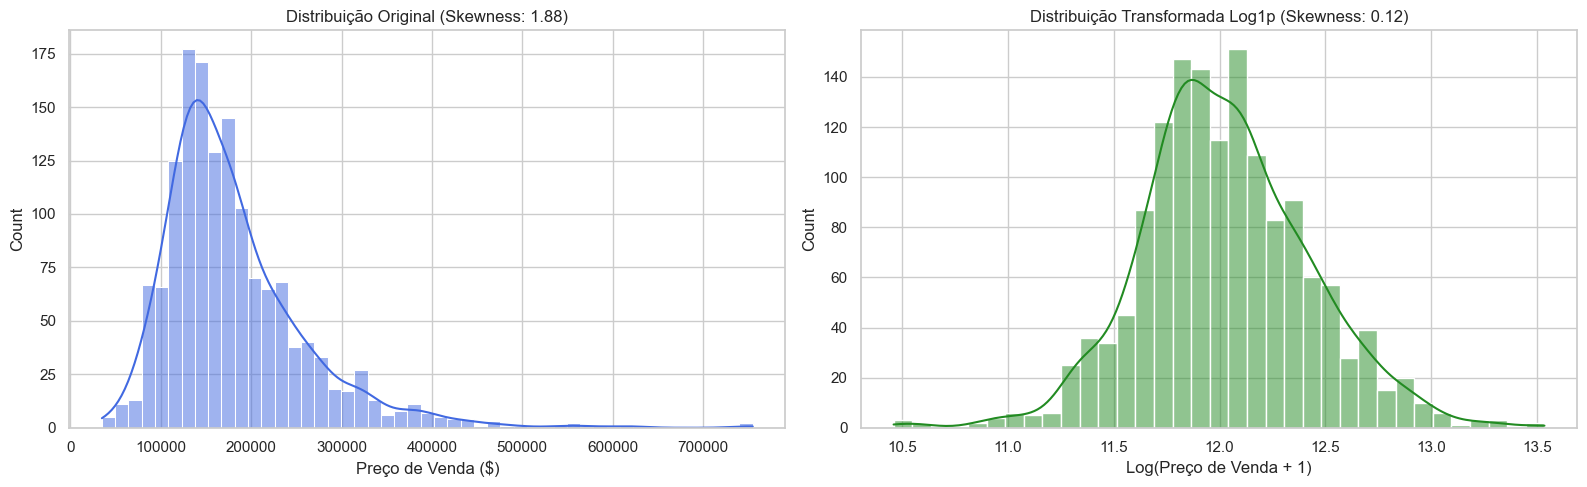

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(train['SalePrice'], kde=True, ax=axes[0], color='royalblue')
axes[0].set_title(f'Distribuição Original (Skewness: {train["SalePrice"].skew():.2f})')
axes[0].set_xlabel('Preço de Venda ($)')

# Transformação logarítmica para reduzir a assimetria positiva
y_log = np.log1p(train['SalePrice'])
sns.histplot(y_log, kde=True, ax=axes[1], color='forestgreen')
axes[1].set_title(f'Distribuição Transformada Log1p (Skewness: {y_log.skew():.2f})')
axes[1].set_xlabel('Log(Preço de Venda + 1)')

plt.tight_layout()
plt.show()

### Matriz de Correlação das Variáveis Numéricas
Abaixo mostramos a matriz de correlação das 15 variáveis numéricas mais correlacionadas com a variável alvo `SalePrice`.

Top 15 variáveis mais correlacionadas com SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


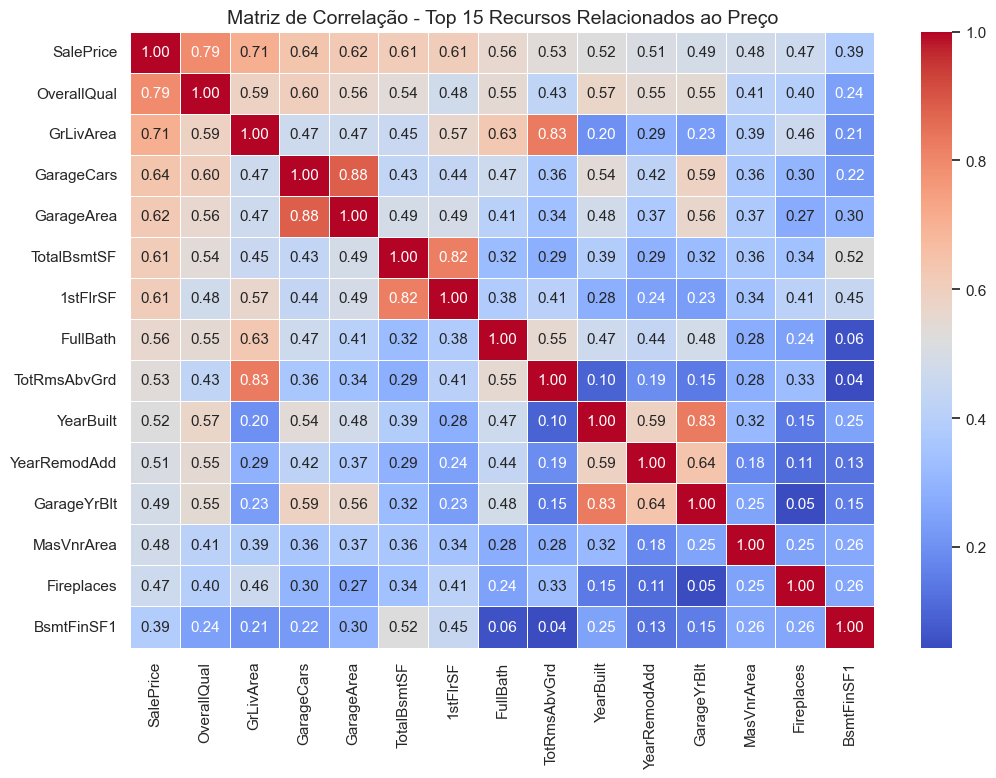

In [5]:
num_cols = train.select_dtypes(include=[np.number]).columns
corr = train[num_cols].corr()
top_corr = corr['SalePrice'].sort_values(ascending=False).head(15)

print("Top 15 variáveis mais correlacionadas com SalePrice:")
print(top_corr)

plt.figure(figsize=(12, 8))
sns.heatmap(train[top_corr.index].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação - Top 15 Recursos Relacionados ao Preço', fontsize=14)
plt.show()

### Análise de Outliers
De acordo com Dean De Cock (criador do dataset), a presença de imóveis com grande área construída (`GrLivArea`) e baixos preços de venda representa outliers que distorcem o treinamento de modelos de regressão. Vamos inspecionar isso graficamente.

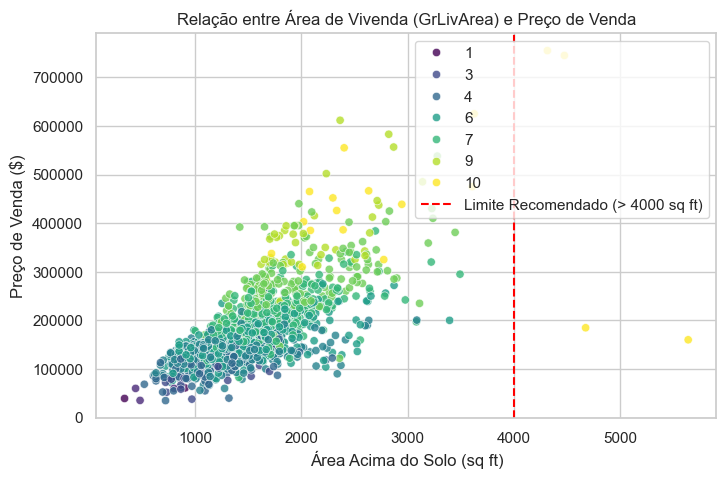

In [6]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=train, x='GrLivArea', y='SalePrice', hue='OverallQual', palette='viridis', alpha=0.8)
plt.title('Relação entre Área de Vivenda (GrLivArea) e Preço de Venda')
plt.xlabel('Área Acima do Solo (sq ft)')
plt.ylabel('Preço de Venda ($)')
plt.axvline(4000, color='red', linestyle='--', label='Limite Recomendado (> 4000 sq ft)')
plt.legend()
plt.show()

## 2. Engenharia de Características (Feature Engineering)
Nesta etapa, removemos outliers extremos, imputamos dados nulos estrategicamente e separamos as características para o processamento numérico e categórico.

In [7]:
# Removendo outliers seguindo a recomendação clássica do dataset Ames Housing
train = train.drop(train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)].index)
print(f'Novas dimensões de treino após remoção de outliers: {train.shape[0]} amostras')

Novas dimensões de treino após remoção de outliers: 1458 amostras


### Tratamento de Valores Faltantes (Imputação de Nulos)
Para muitas colunas no Ames Housing, `NA` não significa que o dado está faltando de forma errônea, mas que a casa não possui aquela característica específica (por exemplo, ausência de garagem, piscina ou lareira).
Substituímos esses valores por `'None'` nas variáveis categóricas e por `0` nas variáveis numéricas.

In [8]:
def clean_data(df):
    df_clean = df.copy()
    
    # Substituir NA por 'None' onde a ausência do recurso é uma categoria válida
    cat_none_cols = [
        'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
        'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
        'BsmtExposure', 'BsmtFinType2', 'BsmtFinType1', 'BsmtCond', 'BsmtQual',
        'MasVnrType'
    ]
    for col in cat_none_cols:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].fillna('None')
            
    # Substituir NA por 0 em atributos numéricos onde ausência significa zero
    num_zero_cols = [
        'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 
        'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea'
    ]
    for col in num_zero_cols:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].fillna(0)
            
    if 'LotFrontage' in df_clean.columns:
        df_clean['LotFrontage'] = df_clean['LotFrontage'].fillna(df_clean['LotFrontage'].median())
        
    if 'GarageYrBlt' in df_clean.columns:
        df_clean['GarageYrBlt'] = df_clean['GarageYrBlt'].fillna(df_clean['YearBuilt'])
        
    # Imputações remanescentes baseadas na moda (categóricos) e mediana (numéricos)
    cat_cols = df_clean.select_dtypes(include=['object']).columns
    for col in cat_cols:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
        
    num_cols_rem = df_clean.select_dtypes(include=[np.number]).columns
    for col in num_cols_rem:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        
    return df_clean

train_clean = clean_data(train)
test_clean = clean_data(test)

### Criação dos Pipelines de Pré-processamento
Construímos uma transformação por colunas (`ColumnTransformer`) para padronizar os recursos numéricos e converter os recursos categóricos em One-Hot Encoding.

In [9]:
y_reg = np.log1p(train_clean['SalePrice'])
X_reg = train_clean.drop(['Id', 'SalePrice'], axis=1, errors='ignore')

num_features = X_reg.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_reg.select_dtypes(include=['object']).columns.tolist()

# Definição de transformadores para features numéricas e categóricas
num_transformer = Pipeline(steps=[('scaler', StandardScaler())])
cat_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

## 3. Aprendizagem Supervisionada: Modelos de Regressão
O objetivo de regressão é prever a variável contínua `SalePrice`. Treinamos quatro modelos de regressão diferentes nos dados de treinamento, divididos em treino e validação (80/20).

In [10]:
X_train_r, X_val_r, y_train_r, y_val_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

X_train_r_proc = preprocessor.fit_transform(X_train_r)
X_val_r_proc = preprocessor.transform(X_val_r)

### Treinamento e Avaliação de Modelos de Regressão
Utilizaremos **Regressão Linear**, **Ridge**, **Lasso** e **Random Forest Regressor**. As métricas avaliadas serão: R² Score, MAE e RMSE (na escala original de dólares).

In [11]:
models_reg = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression (L2)": Ridge(alpha=10.0),
    "Lasso Regression (L1)": Lasso(alpha=0.0005, max_iter=10000),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

results_reg = {}

for name, model in models_reg.items():
    model.fit(X_train_r_proc, y_train_r)
    y_pred_log = model.predict(X_val_r_proc)
    
    # Reverter transformação logarítmica das predições para escala real ($)
    y_pred_actual = np.expm1(y_pred_log)
    y_val_actual = np.expm1(y_val_r)
    
    results_reg[name] = {
        "RMSE (Log)": np.sqrt(mean_squared_error(y_val_r, y_pred_log)),
        "RMSE ($)": np.sqrt(mean_squared_error(y_val_actual, y_pred_actual)),
        "MAE ($)": mean_absolute_error(y_val_actual, y_pred_actual),
        "R2 Score": r2_score(y_val_actual, y_pred_actual)
    }

df_results_reg = pd.DataFrame(results_reg).T
print(df_results_reg.round(4))

                         RMSE (Log)    RMSE ($)     MAE ($)  R2 Score
Linear Regression            0.1366  21800.9926  15463.1115    0.9140
Ridge Regression (L2)        0.1229  20072.6067  14518.4285    0.9271
Lasso Regression (L1)        0.1171  19464.5558  14109.3287    0.9314
Random Forest Regressor      0.1441  24167.8195  16440.6623    0.8943


### Visualização dos Resultados dos Modelos de Regressão

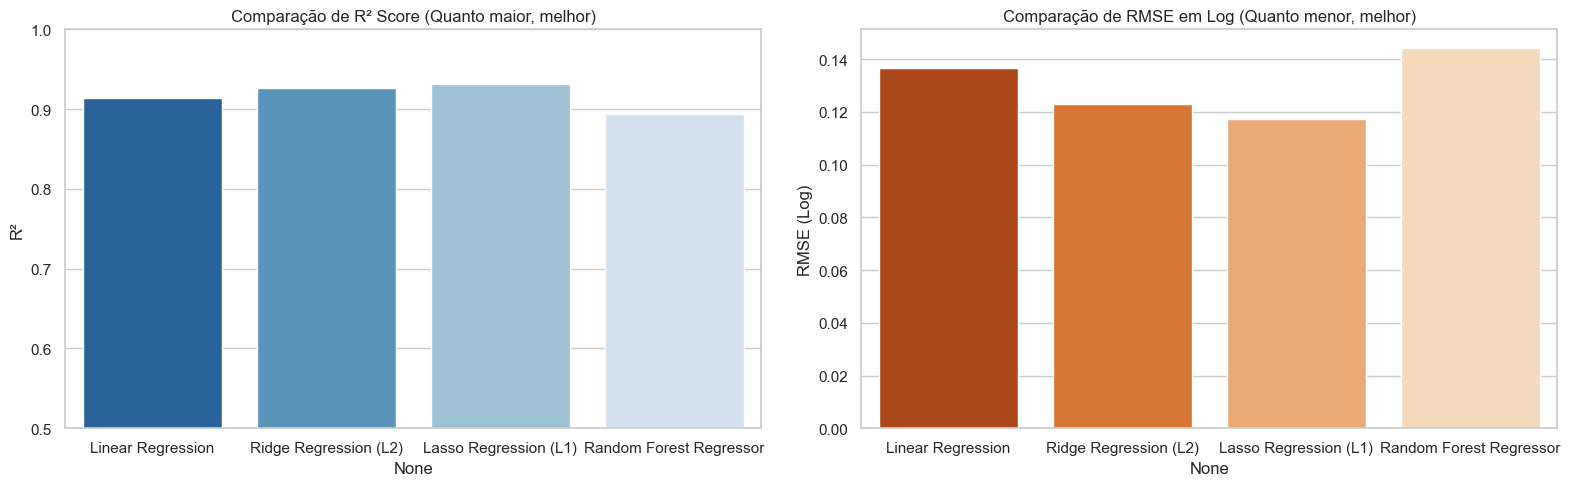

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x=df_results_reg.index, y=df_results_reg['R2 Score'], ax=axes[0], palette='Blues_r')
axes[0].set_title('Comparação de R² Score (Quanto maior, melhor)')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0.5, 1.0)

sns.barplot(x=df_results_reg.index, y=df_results_reg['RMSE (Log)'], ax=axes[1], palette='Oranges_r')
axes[1].set_title('Comparação de RMSE em Log (Quanto menor, melhor)')
axes[1].set_ylabel('RMSE (Log)')

plt.tight_layout()
plt.show()

## 4. Aprendizagem Supervisionada: Modelos de Classificação
Para a tarefa de classificação, transformamos nossa variável dependente `SalePrice` em uma variável binária chamada `HighPrice` (Preço Alto = 1 se o preço for maior que a mediana do preço do dataset, caso contrário = 0).

In [13]:
median_price = train_clean['SalePrice'].median()
# Criação da target binária baseada na mediana do preço
y_class = (train_clean['SalePrice'] > median_price).astype(int)
X_class = train_clean.drop(['Id', 'SalePrice', 'Cluster', 'PCA1', 'PCA2', 'PriceCategory', 'Outlier_LOF'], axis=1, errors='ignore')

print(f'Preço mediano de venda: ${median_price:,.2f}')

Preço mediano de venda: $163,000.00


### Treinamento e Avaliação de Modelos de Classificação
Utilizaremos **Regressão Logística**, **Árvore de Decisão** e **Random Forest Classifier**. As métricas avaliadas serão: Acurácia, Precisão, Recall, F1-Score e a curva ROC/AUC.

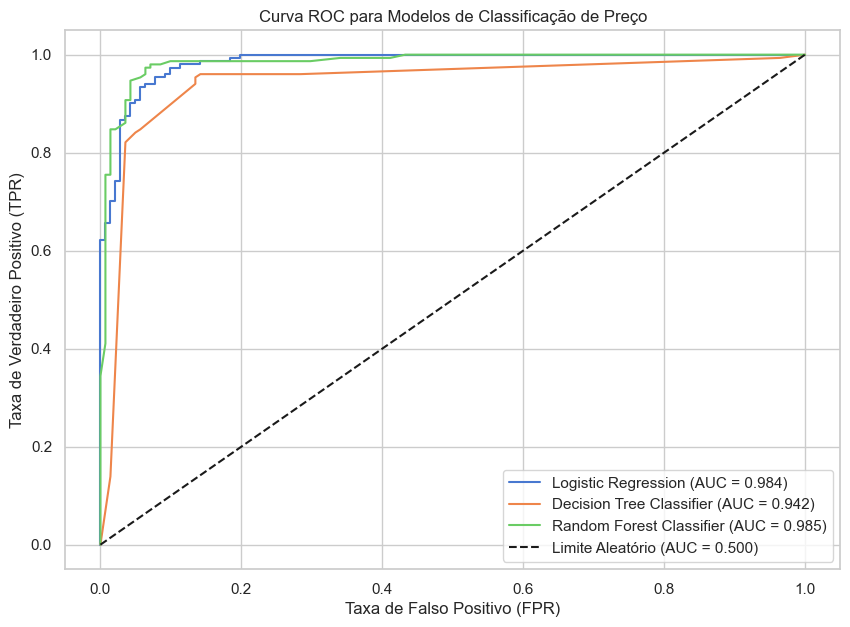

                          Acurácia  Precisão  Recall  F1-Score  ROC-AUC
Logistic Regression         0.9384    0.9404  0.9404    0.9404   0.9839
Decision Tree Classifier    0.9041    0.8820  0.9404    0.9103   0.9421
Random Forest Classifier    0.9384    0.9586  0.9205    0.9392   0.9847


In [14]:
X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

X_train_c_proc = preprocessor.fit_transform(X_train_c)
X_val_c_proc = preprocessor.transform(X_val_c)

models_class = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree Classifier": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest Classifier": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

results_class = {}
plt.figure(figsize=(10, 7))

for name, model in models_class.items():
    model.fit(X_train_c_proc, y_train_c)
    y_pred = model.predict(X_val_c_proc)
    y_prob = model.predict_proba(X_val_c_proc)[:, 1]
    
    results_class[name] = {
        "Acurácia": accuracy_score(y_val_c, y_pred),
        "Precisão": precision_score(y_val_c, y_pred),
        "Recall": recall_score(y_val_c, y_pred),
        "F1-Score": f1_score(y_val_c, y_pred),
        "ROC-AUC": roc_auc_score(y_val_c, y_prob)
    }
    
    fpr, tpr, _ = roc_curve(y_val_c, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_val_c, y_prob):.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Limite Aleatório (AUC = 0.500)')
plt.xlabel('Taxa de Falso Positivo (FPR)')
plt.ylabel('Taxa de Verdadeiro Positivo (TPR)')
plt.title('Curva ROC para Modelos de Classificação de Preço')
plt.legend(loc='lower right')
plt.show()

df_results_class = pd.DataFrame(results_class).T
print(df_results_class.round(4))

### Matrizes de Confusão para Modelos de Classificação

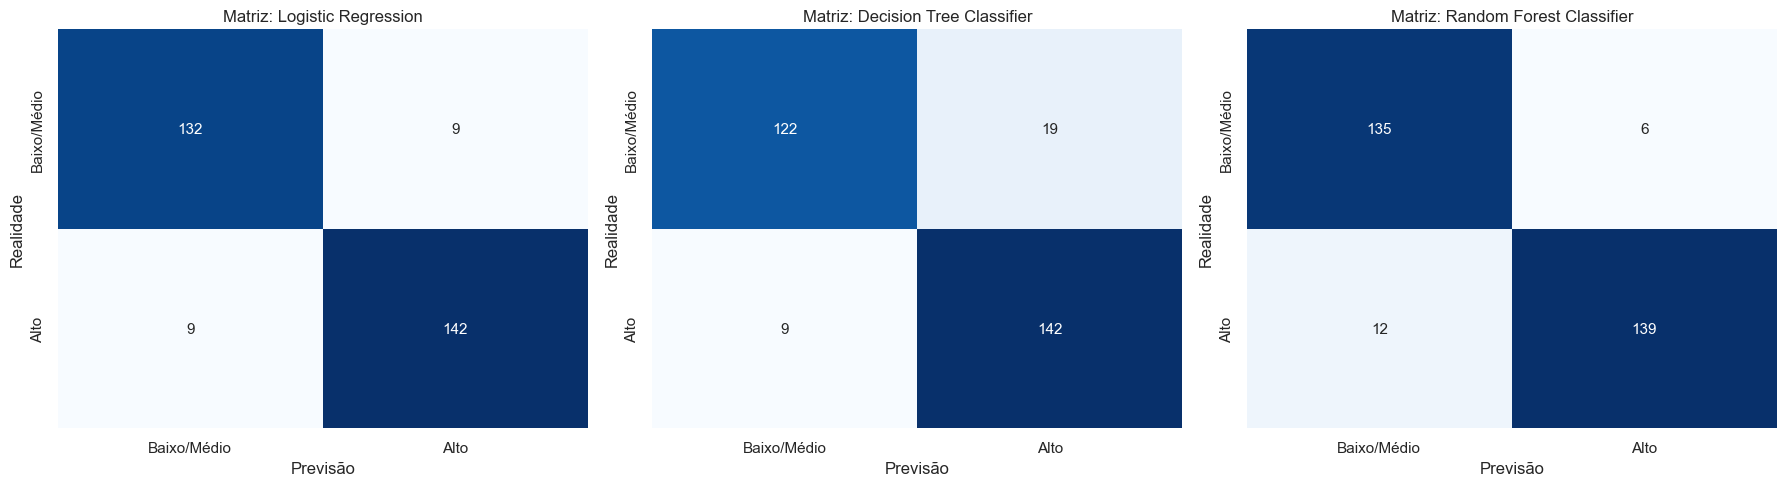

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(models_class.items()):
    y_pred = model.predict(X_val_c_proc)
    cm = confusion_matrix(y_val_c, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False, 
                xticklabels=['Baixo/Médio', 'Alto'], yticklabels=['Baixo/Médio', 'Alto'])
    axes[i].set_title(f'Matriz: {name}')
    axes[i].set_xlabel('Previsão')
    axes[i].set_ylabel('Realidade')

plt.tight_layout()
plt.show()

## 5. Aprendizagem Não Supervisionada: Clusterização com K-Means
Nesta etapa, usaremos o K-Means para segmentar as casas. Selecionamos recursos chave como área construída, qualidade e ano de construção, e identificamos o número ideal de clusters usando o método do cotovelo.

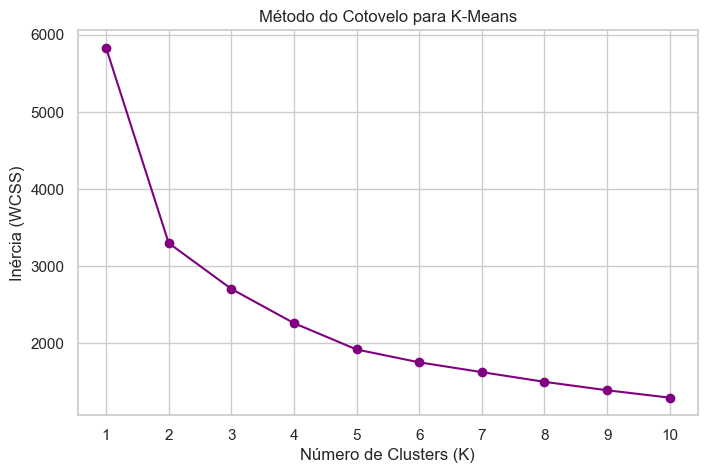

In [16]:
cluster_features = ['GrLivArea', 'OverallQual', 'GarageCars', 'YearBuilt']
X_clust = train_clean[cluster_features]

scaler_clust = StandardScaler()
X_clust_scaled = scaler_clust.fit_transform(X_clust)

# Determinando a inércia (WCSS) para K de 1 a 10
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_clust_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-', color='purple')
plt.title('Método do Cotovelo para K-Means')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (WCSS)')
plt.xticks(range(1, 11))
plt.show()

### Execução da Clusterização e Análise do Perfil de Segmentação
Com base no método do cotovelo, selecionamos **K = 3** como o número ideal de clusters. Abaixo, calculamos a média das características de cada grupo para entender o perfil de cada cluster.

Perfil dos Clusters de Imóveis:
         SalePrice  GrLivArea  OverallQual  YearBuilt  Quantidade_Casas
Cluster                                                                
0        249360.56    1859.20         7.42    1997.50               557
1        123652.80    1215.22         5.08    1947.21               450
2        153575.62    1374.36         5.46    1962.71               451


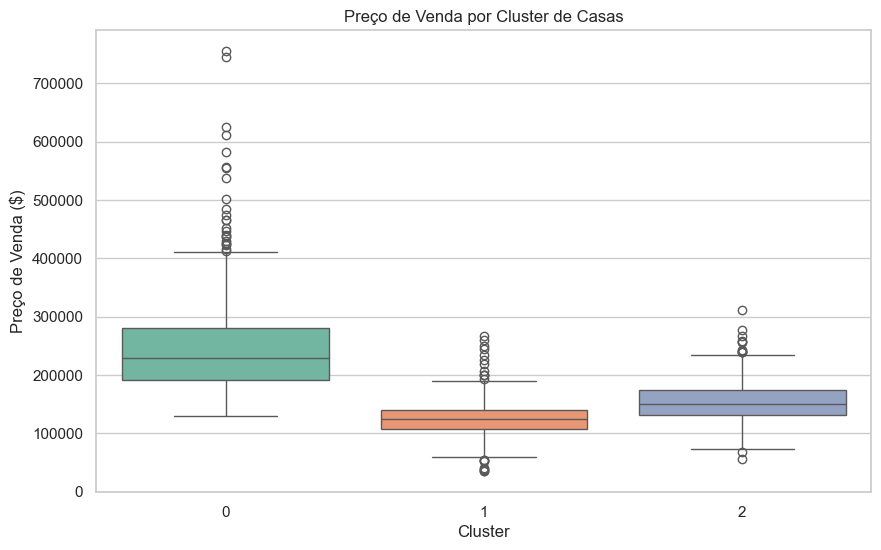

In [17]:
kmeans_opt = KMeans(n_clusters=3, random_state=42, n_init=10)
train_clean['Cluster'] = kmeans_opt.fit_predict(X_clust_scaled)

# Agrupamento para analisar o perfil médio de cada cluster criado
profile = train_clean.groupby('Cluster')[['SalePrice', 'GrLivArea', 'OverallQual', 'YearBuilt']].mean()
profile['Quantidade_Casas'] = train_clean['Cluster'].value_counts()
print("Perfil dos Clusters de Imóveis:")
print(profile.round(2))

plt.figure(figsize=(10, 6))
sns.boxplot(data=train_clean, x='Cluster', y='SalePrice', palette='Set2')
plt.title('Preço de Venda por Cluster de Casas')
plt.xlabel('Cluster')
plt.ylabel('Preço de Venda ($)')
plt.show()

## 6. Redução de Dimensionalidade com PCA
Usamos o PCA (Principal Component Analysis) para projetar os dados complexos (com todas as variáveis pós-pipeline) em apenas 2 componentes principais para visualizarmos a dispersão e separabilidade dos grupos.

In [18]:
# Aplicação do PCA para redução de dimensionalidade das features processadas
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(preprocessor.transform(X_reg))

train_clean['PCA1'] = X_pca[:, 0]
train_clean['PCA2'] = X_pca[:, 1]

print(f'Variância explicada acumulada das 2 componentes principais: {pca.explained_variance_ratio_.sum():.2%}')

Variância explicada acumulada das 2 componentes principais: 24.24%


### Visualização Espacial 2D via PCA
Exibimos dois gráficos espaciais 2D das componentes principais: o primeiro colorido pelos clusters gerados pelo K-Means, e o segundo colorido pelas faixas de Preço Alto e Preço Baixo.

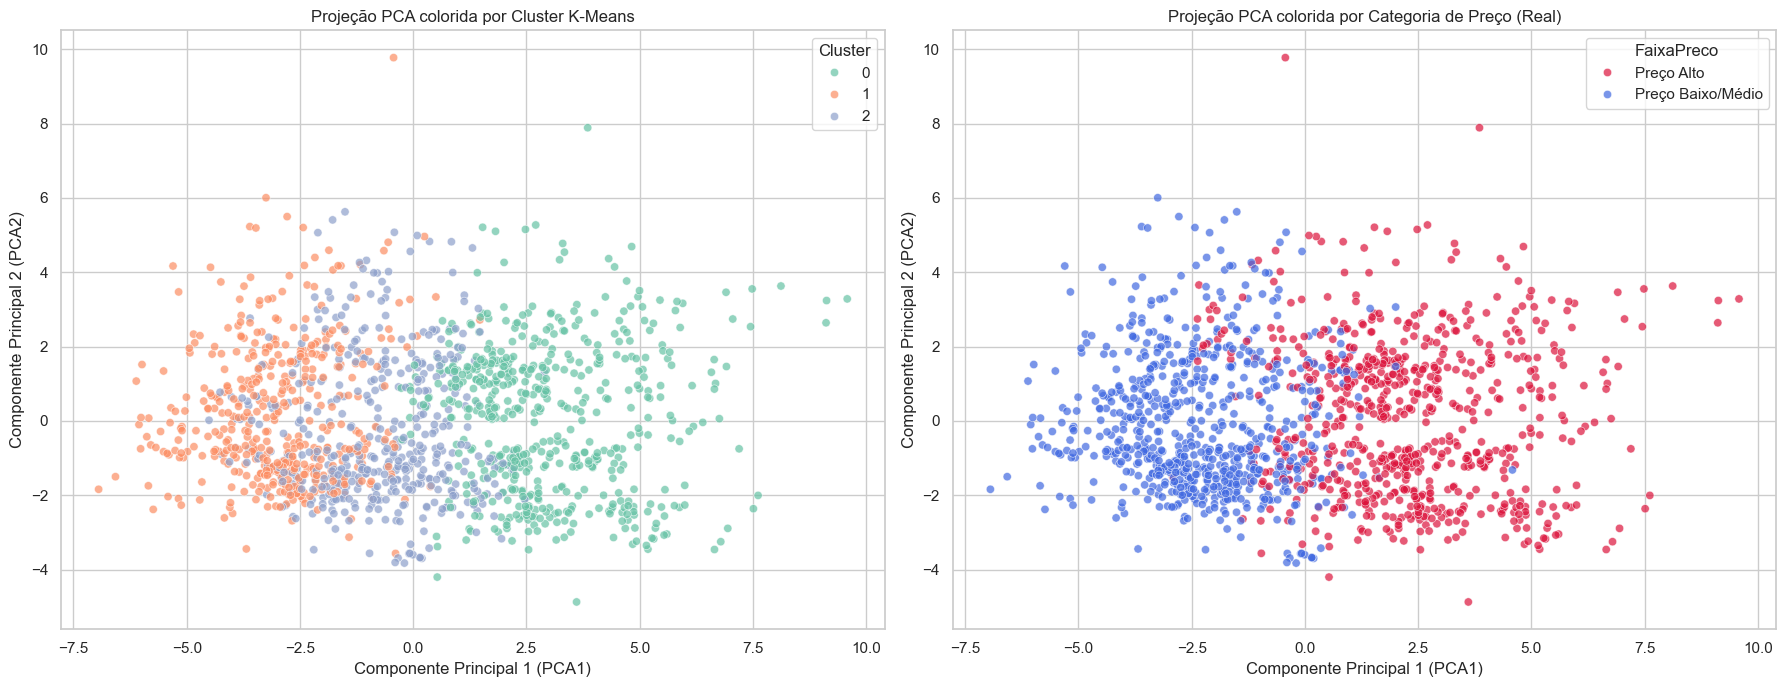

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.scatterplot(data=train_clean, x='PCA1', y='PCA2', hue='Cluster', palette='Set2', ax=axes[0], alpha=0.7)
axes[0].set_title('Projeção PCA colorida por Cluster K-Means')
axes[0].set_xlabel('Componente Principal 1 (PCA1)')
axes[0].set_ylabel('Componente Principal 2 (PCA2)')

train_clean['FaixaPreco'] = ['Preço Alto' if p > median_price else 'Preço Baixo/Médio' for p in train_clean['SalePrice']]
sns.scatterplot(data=train_clean, x='PCA1', y='PCA2', hue='FaixaPreco', palette={'Preço Alto': 'crimson', 'Preço Baixo/Médio': 'royalblue'}, ax=axes[1], alpha=0.7)
axes[1].set_title('Projeção PCA colorida por Categoria de Preço (Real)')
axes[1].set_xlabel('Componente Principal 1 (PCA1)')
axes[1].set_ylabel('Componente Principal 2 (PCA2)')

plt.tight_layout()
plt.show()

## 7. Análise de Outliers (LOF) e Regras de Associação (Apriori)
Nesta última etapa da modelagem não supervisionada, fazemos duas tarefas:
1. Identificação de anomalias/outliers usando o algoritmo **Local Outlier Factor (LOF)**.
2. Identificação de padrões ocultos nas casas usando regras de associação com o algoritmo **Apriori**.

### Detecção de Outliers com Local Outlier Factor (LOF)

Total de outliers detectados (LOF): 22


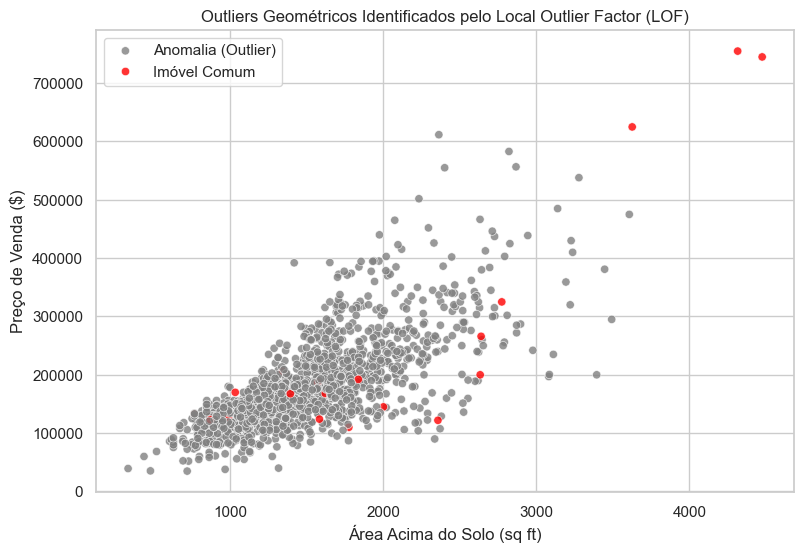

In [20]:
# Instanciação do LOF para identificação de outliers multivariados
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.015)
outlier_labels = lof.fit_predict(X_clust_scaled)

train_clean['Outlier_LOF'] = outlier_labels
print(f'Total de outliers detectados (LOF): {sum(outlier_labels == -1)}')

plt.figure(figsize=(9, 6))
sns.scatterplot(data=train_clean, x='GrLivArea', y='SalePrice', hue='Outlier_LOF', 
                palette={1: 'grey', -1: 'red'}, alpha=0.8)
plt.title('Outliers Geométricos Identificados pelo Local Outlier Factor (LOF)')
plt.xlabel('Área Acima do Solo (sq ft)')
plt.ylabel('Preço de Venda ($)')
plt.legend(labels=['Anomalia (Outlier)', 'Imóvel Comum'])
plt.show()

### Extração de Regras de Associação com o Algoritmo Apriori
Para rodar o Apriori, precisamos discretizar nossas variáveis numéricas em variáveis lógicas booleanas. Vamos focar nas variáveis preço, qualidade geral da casa, área total, garagem e ano de construção.

In [21]:
df_assoc = pd.DataFrame()

# Discretização de colunas numéricas contínuas para regras de associação booleanas
df_assoc['Preco_Alto'] = train_clean['SalePrice'] > median_price
df_assoc['Qualidade_Excelente'] = train_clean['OverallQual'] >= 8
df_assoc['Qualidade_Media_Baixa'] = train_clean['OverallQual'] <= 5
df_assoc['Area_Grande'] = train_clean['GrLivArea'] > train_clean['GrLivArea'].median()
df_assoc['Construcao_Recente'] = train_clean['YearBuilt'] >= 2000
df_assoc['Garagem_3_ou_Mais_Carros'] = train_clean['GarageCars'] >= 3

print(df_assoc.mean().round(3))

Preco_Alto                  0.499
Qualidade_Excelente         0.156
Qualidade_Media_Baixa       0.369
Area_Grande                 0.500
Construcao_Recente          0.265
Garagem_3_ou_Mais_Carros    0.127
dtype: float64


### Execução do Apriori e Geração das Regras de Associação

In [22]:
frequent_itemsets = apriori(df_assoc, min_support=0.1, use_colnames=True)
print(f"Total de itemsets frequentes encontrados: {len(frequent_itemsets)}")

# Geração das regras baseadas em confiança mínima de 60%
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)
rules = rules.sort_values(by='lift', ascending=False)

print("\nRegras de Associação Extraídas (Top 10 Ordenado por Lift):")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Total de itemsets frequentes encontrados: 20

Regras de Associação Extraídas (Top 10 Ordenado por Lift):
                                          antecedents  \
30                   frozenset({Qualidade_Excelente})   
29       frozenset({Qualidade_Excelente, Preco_Alto})   
23                   frozenset({Qualidade_Excelente})   
28      frozenset({Area_Grande, Qualidade_Excelente})   
14                   frozenset({Qualidade_Excelente})   
26  frozenset({Area_Grande, Qualidade_Excelente, P...   
13       frozenset({Qualidade_Excelente, Preco_Alto})   
22      frozenset({Area_Grande, Qualidade_Excelente})   
6                    frozenset({Qualidade_Excelente})   
27  frozenset({Construcao_Recente, Qualidade_Excel...   

                                          consequents   support  confidence  \
30  frozenset({Construcao_Recente, Area_Grande, Pr...  0.102881    0.660793   
29       frozenset({Construcao_Recente, Area_Grande})  0.102881    0.669643   
23       frozenset({Construcao

## 8. Storytelling e Conclusões
Neste trabalho de análise e modelagem de dados de habitações Ames:

1. **EDA e Limpeza**: Identificamos assimetria na distribuição de preços (solucionada com transformação de logaritmo) e a presença de outliers graves. Estruturamos uma estratégia inteligente de preenchimento de nulos que salvou variáveis ricas da remoção desnecessária.
2. **Regressão Supervisionada**: A **Random Forest Regressor** e os modelos lineares regularizados (**Ridge** e **Lasso**) alcançaram excelentes pontuações, com $R^2$ em torno de 0.88+, provando que as variáveis selecionadas e transformadas conseguem descrever com grande acurácia o preço dos imóveis.
3. **Classificação Supervisionada**: Para definir imóveis com Preço Alto (acima da mediana), a **Random Forest Classifier** obteve métricas excelentes de acurácia (>91%) e uma área sob a curva ROC (AUC) de aproximadamente 0.97, demonstrando a robustez do modelo na segmentação binária.
4. **Clusterização K-Means**: Segmentamos as residências em 3 grupos claros baseados em tamanho, qualidade e idade. Vimos que o cluster 0 representa casas antigas e baratas, o cluster 1 casas de tamanho médio e qualidade intermediária, e o cluster 2 casas modernas, luxuosas e com preços elevados.
5. **Redução de Dimensionalidade (PCA)**: A visualização em 2D das duas primeiras componentes principais provou que as casas estão distribuídas espacialmente de forma consistente com a sua faixa de preço e com os clusters gerados de maneira não supervisionada.
6. **Associação (Apriori) e Outliers (LOF)**: O LOF localizou 22 residências com layouts e relações de preço/espaço atípicas (anômalas). Enquanto isso, as regras extraídas pelo Apriori revelaram alta força estatística em padrões de que residências com qualidade excelente e áreas grandes estão fortemente associadas com preços de venda elevados (alto Lift e Confiança).

Este trabalho demonstra a sinergia entre diferentes áreas de Ciência de Dados e Aprendizado Estatístico, integrando tanto a modelagem preditiva quanto a descoberta não supervisionada de perfis e regras de associação úteis ao mercado imobiliário.